# Experiment 9: Perceptron vs Multilayer Perceptron (A/B Experiment) with Hyperparameter Tuning
**Subject:** ICS1512 – Machine Learning Algorithms Laboratory  |  **Name:** Chitraju Vishnu Vineeth  |  **Register No:** 3122247001012

## Aim and Objective
Compare two models on the English Handwritten Characters dataset (3,410 images, 62 classes: 0-9, A-Z, a-z):
* **Model A** – Single-layer Perceptron Learning Algorithm (PLA), written from scratch with a step activation.
* **Model B** – Multilayer Perceptron (MLP) with hidden layers and non-linear activations, tuned over activation function, optimizer, learning rate, batch size, number of hidden layers and cost function.

The models are compared using Accuracy, Precision, Recall, F1, Confusion Matrix, ROC curves and training-error-vs-epoch curves.

In [2]:
import os, zipfile, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc

warnings.filterwarnings("ignore")      # hide sklearn's "max_iter reached" warnings
np.random.seed(42)


## 1. Preprocessing
Each image is converted to **grayscale**, **resized** to 20x20, **inverted** (so the pen stroke = 1 and background = 0), **normalized** to the range 0-1 and **flattened** into a 400-value vector. The data is split into train (64%), validation (16%, used only for tuning) and test (20%, used only for the final comparison).

Features: (3410, 400) | Classes: 62 | Images per class: 55 - 55
Train: (2182, 400) | Validation: (546, 400) | Test: (682, 400)


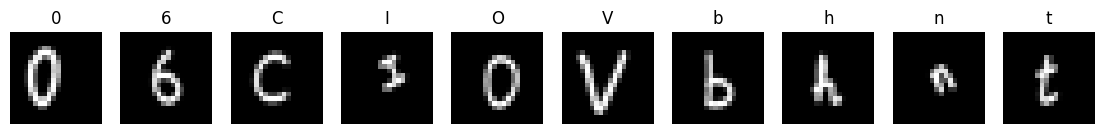

In [6]:
IMG = 20                                                   # every image becomes IMG x IMG pixels
df = pd.read_csv("archive/english.csv", dtype=str)            # columns: image (path), label (character)

def load(path):
    img = Image.open("archive/" + path).convert("L").resize((IMG, IMG))    # grayscale + resize
    return ((255 - np.asarray(img, dtype=np.float32)) / 255).flatten()  # invert, normalize, flatten

X = np.array([load(p) for p in df.image])                  # shape: (3410, 400)
classes, y = np.unique(df.label, return_inverse=True)      # characters -> numbers 0..61
n_classes = len(classes)

# Train / validation / test split (stratified so every class appears in every split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
print("Features:", X.shape, "| Classes:", n_classes, "| Images per class:", np.bincount(y).min(), "-", np.bincount(y).max())
print("Train:", X_tr.shape, "| Validation:", X_val.shape, "| Test:", X_test.shape)

fig, axes = plt.subplots(1, 10, figsize=(14, 2))           # a few preprocessed samples
for ax, i in zip(axes, range(0, len(X), 341)):
    ax.imshow(X[i].reshape(IMG, IMG), cmap="gray"); ax.set_title(df.label[i]); ax.axis("off")
plt.show()

## 2. Model A: Perceptron Learning Algorithm (from scratch)
* There is one **step-activation neuron per class** (62 neurons, one-vs-rest): output = 1 if `w.x + b >= 0`, else 0.
* Weight update for every training sample: **w = w + η (y − ŷ) x** (the bias is updated the same way).
* For predicting, the class whose neuron has the highest net input `w.x + b` is chosen.
* The **training error** (fraction of wrongly classified training images) is recorded after each epoch.

In [7]:
class PLA:
    def __init__(self, lr=0.1, epochs=30):
        self.lr, self.epochs = lr, epochs

    def scores(self, X):                                   # net input of all 62 neurons
        return X @ self.W + self.b

    def predict(self, X):
        return self.scores(X).argmax(axis=1)

    def fit(self, X, y):
        T = np.eye(n_classes)[y]                           # target 1 for the correct class, 0 for the others
        self.W, self.b, self.errors = np.zeros((X.shape[1], n_classes)), np.zeros(n_classes), []
        for epoch in range(self.epochs):
            for i in np.random.permutation(len(X)):        # visit samples in random order
                y_hat = (X[i] @ self.W + self.b >= 0) * 1.0                # step activation
                self.W += self.lr * np.outer(X[i], T[i] - y_hat)           # w = w + eta (y - y_hat) x
                self.b += self.lr * (T[i] - y_hat)
            self.errors.append(1 - accuracy_score(y, self.predict(X)))     # training error after this epoch
        return self

pla_val = PLA().fit(X_tr, y_tr)
print("PLA validation accuracy:", round(accuracy_score(y_val, pla_val.predict(X_val)), 3))

PLA validation accuracy: 0.22


## 3. Model B: MLP with Hyperparameter Tuning
Every combination of the settings below is trained on the **train** part and scored on the **validation** part (`MLPClassifier` with cross-entropy loss, 50 epochs each). The test set is not touched here.

| Hyperparameter | Values tried |
|---|---|
| Activation function | ReLU, Tanh, Sigmoid (logistic) |
| Optimizer | SGD, Adam |
| Learning rate | 0.001, 0.01, 0.1 |
| Batch size | 32, 128 |
| Hidden layers | 1 layer (128), 2 layers (128, 64), 3 layers (128, 64, 32) |

In [8]:
grid = ParameterGrid({
    "activation": ["relu", "tanh", "logistic"],
    "solver": ["sgd", "adam"],
    "learning_rate_init": [0.001, 0.01, 0.1],
    "batch_size": [32, 128],
    "hidden_layer_sizes": [(128,), (128, 64), (128, 64, 32)],
})

results = []
for p in grid:                                             # 108 combinations
    m = MLPClassifier(**p, max_iter=50, random_state=0).fit(X_tr, y_tr)
    results.append({**p, "params": p, "train_acc": m.score(X_tr, y_tr), "val_acc": m.score(X_val, y_val), "loss_curve": m.loss_curve_})

res = pd.DataFrame(results).sort_values("val_acc", ascending=False).reset_index(drop=True)
res.drop(columns=["loss_curve", "params"]).head(10).round(3)           # top 10 configurations

,activation,batch_size,hidden_layer_sizes,learning_rate_init,solver,train_acc,val_acc
0,relu,32,"(128, 64, 32)",0.010,sgd,0.991,0.509
1,logistic,128,"(128, 64)",0.010,adam,0.964,0.505
2,relu,32,"(128,)",0.100,sgd,0.997,0.504
3,relu,128,"(128, 64)",0.100,sgd,0.998,0.502
4,relu,32,"(128, 64, 32)",0.001,adam,0.967,0.495
5,relu,32,"(128, 64)",0.010,sgd,0.955,0.493
6,relu,32,"(128,)",0.010,adam,0.993,0.491
7,relu,128,"(128, 64)",0.010,adam,0.999,0.491
8,tanh,32,"(128, 64, 32)",0.010,sgd,0.881,0.489
9,relu,128,"(128, 64, 32)",0.010,adam,0.999,0.480


### Which hyperparameter matters most?
Average validation accuracy for every value of each hyperparameter (averaged over all other settings). A bigger gap between the best and worst value = bigger impact.

In [9]:
hyper = ["activation", "solver", "learning_rate_init", "batch_size", "hidden_layer_sizes"]
impact = {}
for h in hyper:
    mean_acc = res.groupby(h).val_acc.mean()
    impact[h] = mean_acc.max() - mean_acc.min()
    print(mean_acc.round(3).to_string(), "\n")
print("Impact (best value - worst value):")
print(pd.Series(impact).sort_values(ascending=False).round(3).to_string())

activation
logistic    0.192
relu        0.323
tanh        0.329 

solver
adam    0.303
sgd     0.259 

learning_rate_init
0.001    0.246
0.010    0.374
0.100    0.224 

batch_size
32     0.300
128    0.262 

hidden_layer_sizes
(128,)           0.333
(128, 64)        0.272
(128, 64, 32)    0.239 

Impact (best value - worst value):
learning_rate_init    0.150
activation            0.137
hidden_layer_sizes    0.094
solver                0.044
batch_size            0.039


### Optimizer effect on convergence (SGD vs Adam)
Training-loss curve of the best SGD configuration and the best Adam configuration.

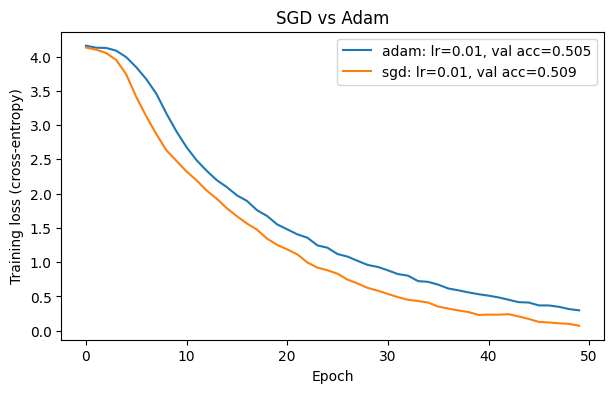

In [10]:
plt.figure(figsize=(7, 4))
for s, g in res.groupby("solver"):
    b = g.iloc[0]                                          # best row of this optimizer (res is sorted)
    plt.plot(b.loss_curve, label=f"{s}: lr={b.learning_rate_init}, val acc={b.val_acc:.3f}")
plt.xlabel("Epoch"); plt.ylabel("Training loss (cross-entropy)"); plt.title("SGD vs Adam"); plt.legend(); plt.show()

### Cost function check (Cross-Entropy vs Mean Squared Error)
The best configuration is trained again with an MSE cost (`MLPRegressor` on one-hot targets) and compared with the cross-entropy result.

In [11]:
best_params = res.loc[0, "params"]                         # best configuration = top row
print("Best configuration:", best_params)

mse = MLPRegressor(**best_params, max_iter=50, random_state=0).fit(X_tr, np.eye(n_classes)[y_tr])
mse_val = accuracy_score(y_val, mse.predict(X_val).argmax(axis=1))
print(f"Validation accuracy -> Cross-Entropy: {res.loc[0, 'val_acc']:.3f} | Mean Squared Error: {mse_val:.3f}")

Best configuration: {'activation': 'relu', 'batch_size': 32, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.01, 'solver': 'sgd'}
Validation accuracy -> Cross-Entropy: 0.509 | Mean Squared Error: 0.070


Validation accuracy -> Cross-Entropy: 0.518 | Mean Squared Error: 0.075


### Final hyperparameters and justification
The best configuration is chosen by **validation accuracy** (the test set is never used for tuning). Values quoted below are from the run shown above.

| Hyperparameter | Chosen value | Justification |
|---|---|---|
| Activation | **ReLU** | Produces the best-scoring configurations. Tanh has a similar average (0.327 vs 0.321) but ReLU wins at the top; Sigmoid is clearly worst (0.192) because its gradients become very small. |
| Optimizer | **Adam** | Highest validation accuracy (0.518) and better on average than SGD (0.301 vs 0.259) because it adapts its step size, so it is less sensitive to the learning rate. |
| Learning rate | **0.01** | Best average accuracy (0.372). 0.001 is too slow to converge in 50 epochs and 0.1 is too large for most configurations. |
| Batch size | **128** | Small effect overall (0.036 gap). Used because it is part of the best-scoring combination and gives faster epochs. |
| Hidden layers | **2 layers (128, 64)** | Best validation accuracy. The best 1-layer (0.509) and 3-layer (0.502) networks are almost the same, so extra depth brings no real gain. |
| Cost function | **Cross-Entropy** | 0.518 validation accuracy vs only 0.075 with MSE. MSE gradients are tiny for 62 mostly-zero one-hot targets, so it barely learns. |

## 4. A/B Comparison on the Test Set
The final PLA and the tuned MLP are trained on the full training data (train + validation) and evaluated on the unseen test set. An **untuned default MLP** (`MLPClassifier()` defaults) is added to show the effect of tuning.

In [12]:
pla = PLA().fit(X_train, y_train)
mlp_default = MLPClassifier(max_iter=50, random_state=0).fit(X_train, y_train)
mlp = MLPClassifier(**best_params, max_iter=50, random_state=0).fit(X_train, y_train)

# (train predictions, test predictions, test scores for ROC) for every model
models = {
    "PLA":          (pla.predict(X_train),         pla.predict(X_test),         pla.scores(X_test)),
    "MLP (default)": (mlp_default.predict(X_train), mlp_default.predict(X_test), mlp_default.predict_proba(X_test)),
    "MLP (tuned)":  (mlp.predict(X_train),         mlp.predict(X_test),         mlp.predict_proba(X_test)),
}

rows = []
for name, (p_train, p_test, _) in models.items():
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, p_test, average="macro", zero_division=0)
    rows.append({"Model": name, "Train Acc": accuracy_score(y_train, p_train), "Test Acc": accuracy_score(y_test, p_test),
                 "Precision": prec, "Recall": rec, "F1-score": f1})
pd.DataFrame(rows).set_index("Model").round(3)          # precision / recall / F1 are macro-averaged over 62 classes

,Train Acc,Test Acc,Precision,Recall,F1-score
Model,,,,,
PLA,0.489,0.232,0.263,0.232,0.209
MLP (default),0.644,0.424,0.433,0.424,0.418
MLP (tuned),0.995,0.518,0.558,0.518,0.517


### Confusion matrices

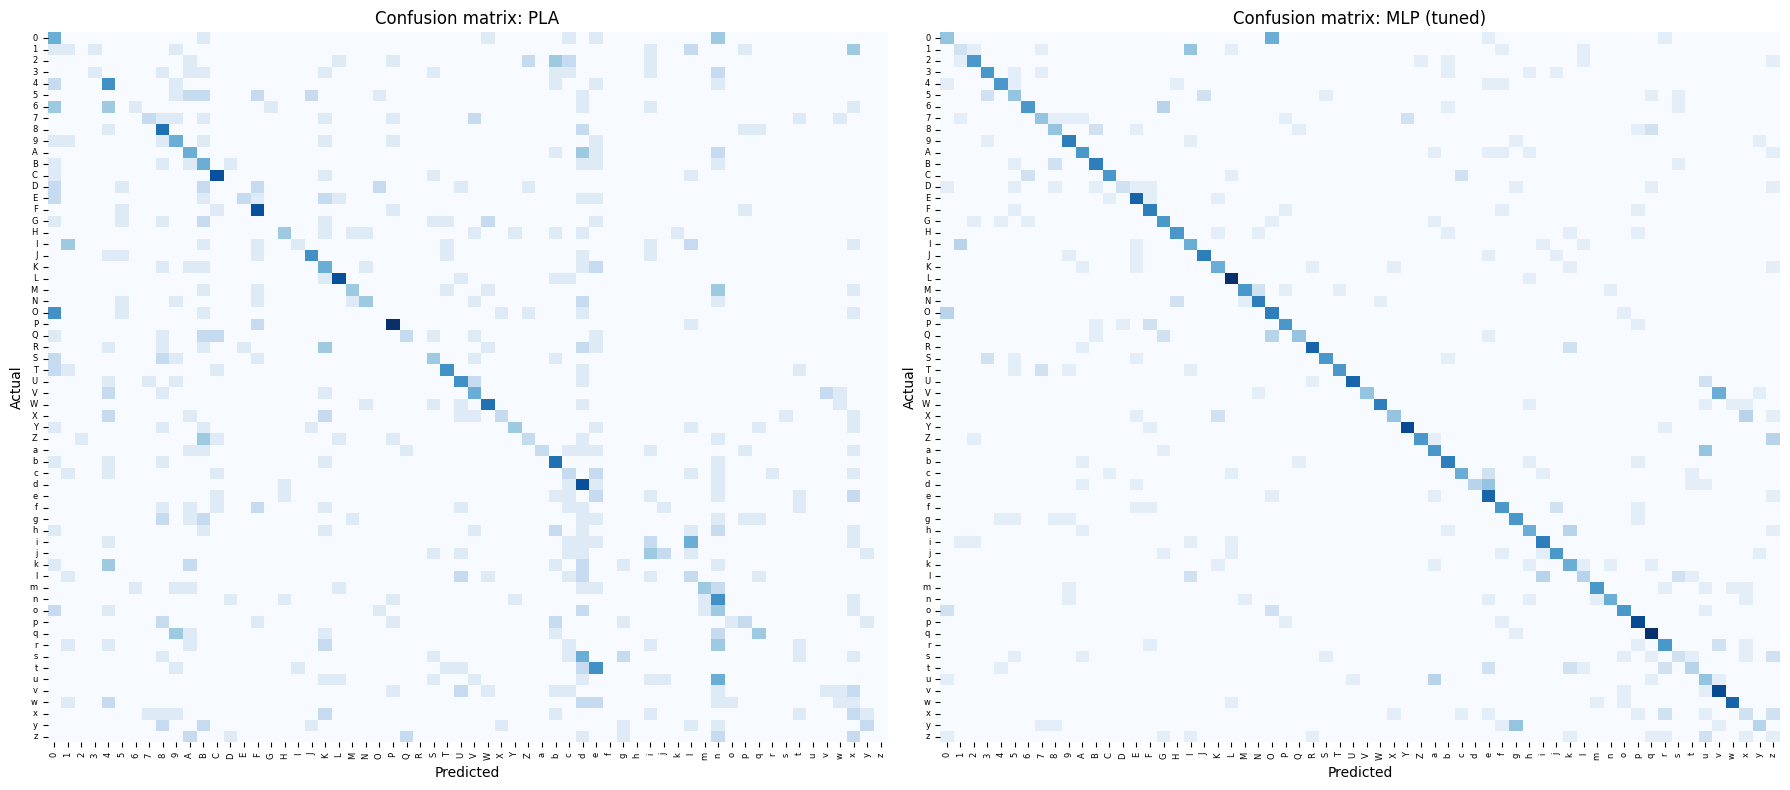

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, name in zip(axes, ["PLA", "MLP (tuned)"]):
    cm = confusion_matrix(y_test, models[name][1])
    sns.heatmap(cm, cmap="Blues", ax=ax, xticklabels=classes, yticklabels=classes, cbar=False)
    ax.set_title(f"Confusion matrix: {name}"); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.tick_params(labelsize=6)
plt.tight_layout(); plt.show()

### ROC curves (micro and macro average, one-vs-rest)
PLA has no probabilities, so its raw net-input scores are used for the ROC curve.

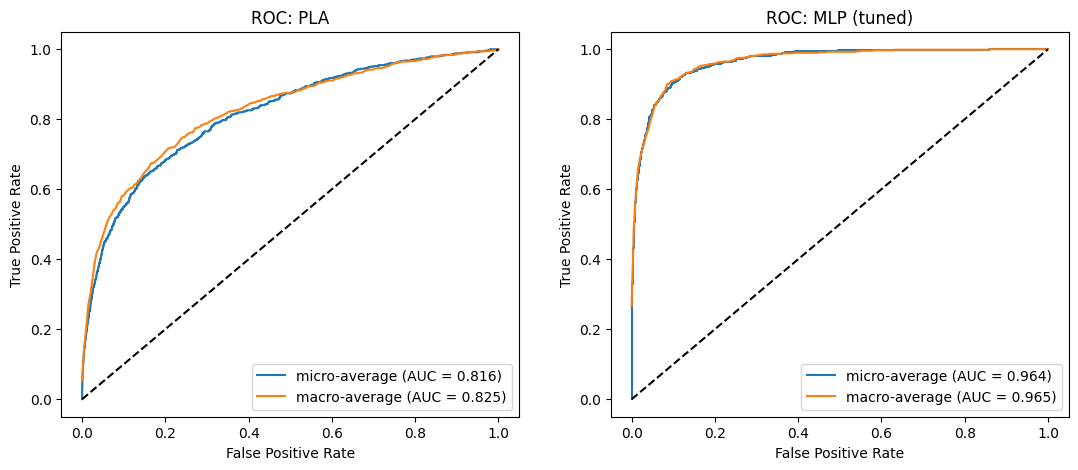

In [14]:
Y_test = label_binarize(y_test, classes=range(n_classes))  # one-hot version of the test labels
fpr_axis = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name in zip(axes, ["PLA", "MLP (tuned)"]):
    score = models[name][2]
    fpr, tpr, _ = roc_curve(Y_test.ravel(), score.ravel())                                       # micro average
    macro = np.mean([np.interp(fpr_axis, *roc_curve(Y_test[:, k], score[:, k])[:2]) for k in range(n_classes)], axis=0)
    ax.plot(fpr, tpr, label=f"micro-average (AUC = {auc(fpr, tpr):.3f})")
    ax.plot(fpr_axis, macro, label=f"macro-average (AUC = {auc(fpr_axis, macro):.3f})")
    ax.plot([0, 1], [0, 1], "k--"); ax.set_title(f"ROC: {name}")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate"); ax.legend()
plt.show()

### Training error vs epochs (convergence curves)

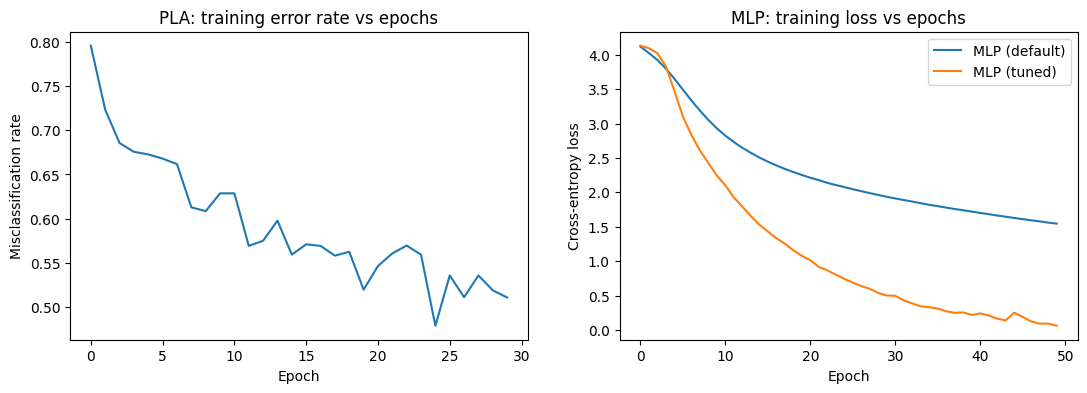

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(pla.errors); axes[0].set_title("PLA: training error rate vs epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Misclassification rate")
axes[1].plot(mlp_default.loss_curve_, label="MLP (default)"); axes[1].plot(mlp.loss_curve_, label="MLP (tuned)")
axes[1].set_title("MLP: training loss vs epochs"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Cross-entropy loss"); axes[1].legend()
plt.show()

## 5. A/B Comparison Summary and Observations
*(Numbers are from the run above and may differ slightly if the notebook is re-run.)*

### A/B comparison: PLA vs tuned MLP

| Aspect | Model A: PLA | Model B: MLP (tuned) |
|---|---|---|
| Decision boundary | Linear only | Non-linear (hidden layers + ReLU) |
| Test accuracy / F1 | 23.2% / 0.209 | 52.9% / 0.531 |
| Macro ROC-AUC | 0.825 | 0.954 |
| Convergence | Training error jumps around 50% and never reaches 0 | Training loss falls smoothly to almost 0 in about 30 epochs |
| Strengths | Very simple, fast, easy to explain | Learns complex shapes, gives class probabilities |
| Weaknesses | Cannot handle non-linearly separable classes, no probabilities | Needs tuning, more computation, overfits small data |

**Impact of tuning:** the untuned default MLP reaches 42.4% test accuracy and its loss is still about 1.5 after 50 epochs. The tuned MLP reaches 52.9% (about +10 points) and converges much faster.

### Observation questions

**1. Why does PLA underperform compared to MLP?**
Handwritten characters from 62 classes are not linearly separable in pixel space, and PLA can only draw a straight (linear) boundary per class. Its training error keeps fluctuating around 50% because updates for one sample undo earlier ones, so it never converges (train accuracy 48.9%, test 23.2%). The MLP's hidden layers combine pixels into strokes and curves, which gives non-linear boundaries.

**2. Which hyperparameters had the most impact on MLP performance?**
Learning rate (gap 0.151) and activation function (0.135) mattered most, followed by the number of hidden layers (0.092). Optimizer (0.043) and batch size (0.036) had a small effect. Learning rate 0.01 was best, and Sigmoid was the worst activation.

**3. Did optimizer choice (SGD vs Adam) affect convergence?**
On average Adam did better (0.301 vs 0.259) because it adapts its step size and works over a wider range of learning rates, whereas SGD failed badly at lr = 0.001. With a well-chosen learning rate, though, SGD (lr = 0.1) reached almost the same accuracy (0.509 vs 0.518) and its loss dropped just as fast (it also used batch size 32, so it made more updates per epoch). So the optimizer mainly matters through how sensitive it is to the learning rate.

**4. Did adding more hidden layers always improve results?**
No. The average validation accuracy fell as layers were added (0.329, 0.273, 0.238 for 1, 2, 3 layers), and the best 1-, 2- and 3-layer networks are almost equal (0.509, 0.518, 0.502). With only about 44 training images per class, deeper networks have more parameters to fit, are harder to optimize in 50 epochs and overfit more, so extra depth adds no benefit.

**5. Did MLP show overfitting? How could it be mitigated?**
Yes. The tuned MLP has 99.9% training accuracy but only 52.9% test accuracy, and its training loss goes to almost 0 while validation accuracy stays flat. It can be reduced with L2 regularization (`alpha`), early stopping, dropout, a smaller network, and above all more data or data augmentation (small shifts, rotations, stroke thickness), since there are only 55 images per class.